# Movie Recommendation System — Model Training Notebook

**Project:** Content-Based Movie Recommendation System
**Author:** Umesh Regmi's Student — Final Project
**Goal:** Build a content-based recommendation engine that, given a movie title, suggests similar movies based on genres, keywords, cast, and director.

This notebook covers:
1. Loading and exploring the dataset
2. Data cleaning & preprocessing
3. Feature engineering (combining text features into "tags")
4. Vectorization (CountVectorizer)
5. Computing cosine similarity
6. Testing the recommendation function
7. Saving the trained artifacts for use in the Django web app


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import ast

pd.set_option('display.max_colwidth', 100)


## 1. Load the Dataset

We use a merged, cleaned version of the **TMDB 5000 Movies Dataset**, which already contains `genres`, `keywords`, `cast`, `crew`, and `director` as plain text columns.

In [11]:
df = pd.read_csv('/home/aura/Downloads/FinalProject_MovieRecommendation/dataset/movie_dataset.csv')
print('Shape:', df.shape)
df.head(3)


Shape: (4803, 24)


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony society,en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, ...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'department': 'Editing', 'job': 'Editor', 'credit_id...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trading company love of one's life,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of t...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,"[{'name': 'Dariusz Wolski', 'gender': 2, 'department': 'Camera', 'job': 'Director of Photography...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. Whil...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,"[{'name': 'Thomas Newman', 'gender': 2, 'department': 'Sound', 'job': 'Original Music Composer',...",Sam Mendes


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

## 2. Explore the Data

A quick look at missing values and a simple visualization of the most common genres.

In [13]:
print('Missing values in key columns:')
df[['title', 'genres', 'keywords', 'cast', 'director', 'overview']].isnull().sum()


Missing values in key columns:


title         0
genres       28
keywords    412
cast         43
director     30
overview      3
dtype: int64

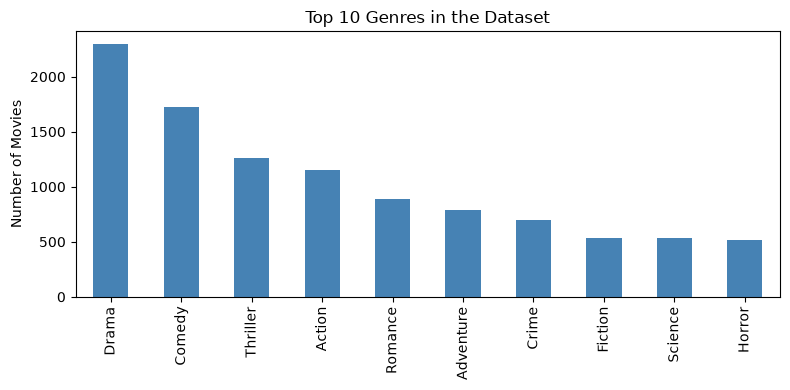

In [14]:
# Quick look at the most frequent genres (for the report / video)
genre_counts = {}
for g in df['genres'].dropna():
    for token in str(g).split():
        genre_counts[token] = genre_counts.get(token, 0) + 1

top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(10)
top_genres.plot(kind='bar', figsize=(8, 4), color='steelblue', title='Top 10 Genres in the Dataset')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('top_genres.png')
plt.show()


## 3. Data Cleaning & Feature Engineering

For a **content-based** recommender, we need a single text field per movie that captures what the movie is "about". We combine:

- `genres`
- `keywords`
- `cast` (top actors)
- `director`
- `overview` (plot summary)

into one combined column called **`tags`**.


In [15]:
# Keep only the columns we need
features = ['index', 'title', 'genres', 'keywords', 'cast', 'director', 'overview', 'vote_average', 'release_date']
movies = df[features].copy()

# Fill missing text values with empty strings so concatenation doesn't break
for col in ['genres', 'keywords', 'cast', 'director', 'overview']:
    movies[col] = movies[col].fillna('')

movies.head(3)


,index,title,genres,keywords,cast,director,overview,vote_average,release_date
0,0,Avatar,Action Adventure Fantasy Science Fiction,culture clash future space war space colony society,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,James Cameron,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, ...",7.2,2009-12-10
1,1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,ocean drug abuse exotic island east india trading company love of one's life,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,Gore Verbinski,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of t...",6.9,2007-05-19
2,2,Spectre,Action Adventure Crime,spy based on novel secret agent sequel mi6,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,Sam Mendes,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. Whil...,6.3,2015-10-26


In [16]:
def clean_text(text):
    # lowercase and remove extra spaces so 'Science Fiction' etc. stay consistent
    return str(text).lower()

movies['tags'] = (
    movies['genres'] + ' ' +
    movies['keywords'] + ' ' +
    movies['cast'] + ' ' +
    movies['director'] + ' ' +
    movies['overview']
).apply(clean_text)

movies[['title', 'tags']].head(3)


,title,tags
0,Avatar,action adventure fantasy science fiction culture clash future space war space colony society sam...
1,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exotic island east india trading company love of one's...
2,Spectre,action adventure crime spy based on novel secret agent sequel mi6 daniel craig christoph waltz l...


## 4. Vectorization

We convert the `tags` text into numeric vectors using **CountVectorizer** (Bag of Words), keeping the 5000 most frequent words and removing common English stopwords.

In [17]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(movies['tags']).toarray()
print('Vector matrix shape:', vectors.shape)


Vector matrix shape: (4803, 5000)


## 5. Compute Cosine Similarity

Cosine similarity measures how similar two movies are based on their tag vectors. We precompute the full similarity matrix once so the web app can look up recommendations instantly (no retraining at request time).

In [18]:
similarity = cosine_similarity(vectors)
similarity = similarity.astype('float32')  # keep the saved file small
print('Similarity matrix shape:', similarity.shape)


Similarity matrix shape: (4803, 4803)


## 6. Build & Test the Recommendation Function

In [19]:
def recommend(movie_title, top_n=5):
    matches = movies[movies['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        return f"'{movie_title}' not found in the dataset."
    idx = matches.index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    return movies.iloc[[i for i, _ in scores]][['title', 'vote_average']]

recommend('Avatar')


,title,vote_average
1531,Moonraker,5.9
461,Lost in Space,5.0
94,Guardians of the Galaxy,7.9
1914,Lifeforce,6.2
2198,Lockout,5.8


In [20]:
recommend('The Dark Knight Rises')


,title,vote_average
119,Batman Begins,7.5
65,The Dark Knight,8.2
1359,Batman,7.0
299,Batman Forever,5.2
428,Batman Returns,6.6


## 7. A Simple Evaluation

Because this is an unsupervised, content-based system (no user ratings/ground truth labels), we evaluate it qualitatively and with a simple **genre-overlap score**: for a sample of movies, what fraction of the recommended movies share at least one genre with the query movie? A higher score suggests the recommendations are thematically consistent.


In [21]:
def genre_overlap_score(movie_title, top_n=5):
    matches = movies[movies['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        return None
    idx = matches.index[0]
    query_genres = set(movies.loc[idx, 'genres'].lower().split())
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    overlaps = []
    for i, _ in scores:
        rec_genres = set(movies.loc[i, 'genres'].lower().split())
        overlaps.append(1 if query_genres & rec_genres else 0)
    return sum(overlaps) / len(overlaps)

sample_titles = ['Avatar', 'The Dark Knight Rises', 'Iron Man', 'Titanic', 'The Matrix']
sample_scores = {t: genre_overlap_score(t) for t in sample_titles if genre_overlap_score(t) is not None}
sample_scores


{'Avatar': 1.0,
 'The Dark Knight Rises': 1.0,
 'Iron Man': 1.0,
 'Titanic': 0.6,
 'The Matrix': 1.0}

In [25]:
avg_score = sum(sample_scores.values()) / len(sample_scores)
print(f'Average genre-overlap score across sample movies: {avg_score:.2f}')


Average genre-overlap score across sample movies: 0.92


## 8. Save the Trained Artifacts

We save:
- `movies.pkl` — the cleaned movies table (title, genres, overview, rating, etc.)
- `similarity.pkl` — the precomputed cosine similarity matrix

Both files are loaded by the Django app at startup so recommendations are served instantly without retraining.


In [26]:
movies_export = movies[['title', 'genres', 'overview', 'vote_average', 'release_date']].reset_index(drop=True)

with open('/recommender/ml_model/movies.pkl', 'wb') as f:
    pickle.dump(movies_export, f)

with open('/recommender/ml_model/similarity.pkl', 'wb') as f:
    pickle.dump(similarity, f)

print('Saved movies.pkl and similarity.pkl')
print('movies.pkl rows:', len(movies_export))


Saved movies.pkl and similarity.pkl
movies.pkl rows: 4803


## 9. Conclusion

We built a content-based movie recommendation engine using `CountVectorizer` + `cosine similarity` on combined movie metadata (genres, keywords, cast, director, overview). The trained artifacts (`movies.pkl`, `similarity.pkl`) are consumed directly by the Django web application (see the `recommender` app's `views.py`) to serve real-time recommendations through a web UI.
